# Hybrid Deep Learning Models (CNN–MLP–RNN) for Fashion-MNIST Classification
# By Asrar Qassem

Overview of what i accomplishment in this project, To create a committee of three diverse deep-learning models using the Fashion MNIST dataset and evaluate their performance both individually and collectively, I follow these steps:

### A. Formation of Diverse Deep-Learning Models

1. **Selection of Models**: Three different neural network architectures are chosen. For diversity, I use:
   - **Convolutional Neural Network (CNN)**: Effective for image data due to its ability to capture spatial hierarchies in images.
   - **Multilayer Perceptron (MLP)**: A basic neural network with fully connected layers. It's less specialized for images but can still provide valuable insights.
   - **Recurrent Neural Network (RNN)** or **Long Short-Term Memory (LSTM)**: Unconventional for image classification, but could capture different patterns in data.

2. **Training**: Each model is trained separately on the Fashion MNIST dataset. This dataset contains grayscale images of fashion products, categorized into 10 classes.

3. **Tuning**: Adjust hyperparameters (like the number of layers, neurons per layer, learning rate, etc.) for each model to ensure they learn differently.


### B. Combining the Three Diverse Models
The three models are combined at the score level through averaging:


1. **Model Diversity**: The committee consists of three different types of neural network architectures:
   - **CNN (Convolutional Neural Network)**: Optimized for image data, capturing spatial hierarchies.
   - **MLP (Multilayer Perceptron)**: A basic fully connected neural network.
   - **RNN (Recurrent Neural Network)**: Processes data sequentially, useful for capturing temporal dynamics, adapted here for image classification.

2. **Score Level Fusion**:
   - Each model independently processes the input image and outputs a probability distribution over the possible classes.
   - These probability distributions represent the confidence of each model in assigning the input image to each of the possible classes.

3. **Averaging Output Probabilities**:
   - The committee's final prediction for a given input image is obtained by averaging these probability distributions across all models.
   - This means that for each class, the committee calculates the mean of the probabilities assigned to that class by each of the three models.

4. **Decision Rule**:
   - The class with the highest average probability is chosen as the final prediction by the committee.


### C. Evaluation Metrics

To evaluate each model and the committee I used the following metrics:

- **F1-Score**: Harmonic mean of precision and recall, giving a balance between the two.
- **Precision**: Proportion of true positives among all predicted positives.
- **Recall**: Proportion of true positives among all actual positives.
- **Accuracy**: Overall proportion of correct predictions.

### Implementation

1. **Model Training and Evaluation**: Train each model on the Fashion MNIST dataset and evaluate their individual performance using the above metrics.
2. **Committee Evaluation**: Evaluate the committee (ensemble) using the same metrics, but with predictions made by averaging the outputs of the three models.

### Tabulation of Results

The table of Results is created with the following structure:

| Model/Committee | F1-Score | Precision | Recall | Accuracy |
|-----------------|----------|-----------|--------|----------|
| CNN Model       |          |           |        |          |
| MLP Model       |          |           |        |          |
| RNN/LSTM Model  |          |           |        |          |
| Committee       |          |           |        |          |



### 1. Import necessary libraries: 
I'll use TensorFlow/Keras for building the models and Scikit-learn for evaluation metrics.

In [2]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 MB 7.6 MB/s  0:00:29m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 7.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 8.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 10.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 9.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 7.4 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [tensorflow]6 [tensorflow]


In [4]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, LSTM, Reshape
from sklearn.metrics import classification_report, accuracy_score
import numpy as bnp
import pandas as pd
from datetime import datetime
from tensorflow import keras

### 2. Loading and Preprocessing the Data
Fashion MNIST is a dataset available directly in TensorFlow

In [5]:
# Load and preprocess the Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
train_images = train_images / 255.0
test_images = test_images / 255.0
train_labels_categorical = to_categorical(train_labels)
test_labels_categorical = to_categorical(test_labels)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
# Reshape data for different models
train_images_cnn = train_images.reshape(-1, 28, 28, 1)
test_images_cnn = test_images.reshape(-1, 28, 28, 1)
train_images_mlp = train_images.reshape(-1, 784)
test_images_mlp = test_images.reshape(-1, 784)
train_images_lstm = train_images.reshape(-1, 28, 28)
test_images_lstm = test_images.reshape(-1, 28, 28)

### 3. Model Building:
 Building the Models
You'll build three different models - CNN, MLP, and LSTM

**CNN:** Consists of convolutional layers followed by max-pooling and fully connected layers.

**MLP:** Consists of densely connected layers.

**LSTM:** Uses LSTM layers, and requires reshaping the input data to fit the temporal sequence model



In [7]:
# Define the models
# a. Convolutional Neural Network (CNN)
def build_cnn_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

#b. Multilayer Perceptron (MLP)
def build_mlp_model():
    model = Sequential([
        Dense(512, activation='relu', input_shape=(784,)),
        Dense(256, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# c. Long Short-Term Memory (LSTM)
def build_lstm_model():
    model = Sequential([
        # Input LSTM layer with return_sequences=True to allow the next LSTM layer to receive sequence data
        LSTM(128, return_sequences=True, input_shape=(28, 28)),
        # Dropout for regularization
        tf.keras.layers.Dropout(0.2),

        # Second LSTM layer, can experiment with the number of units
        LSTM(64, return_sequences=True),
        tf.keras.layers.Dropout(0.2),

        # Third LSTM layer, no return_sequences as we do not need to pass sequences to further layers
        LSTM(64),
        tf.keras.layers.Dropout(0.2),

        # Dense layers for classification
        Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

### Combining the Diverse Models
The models are combined at the score level:

1. **Averaging Output Probabilities `committee_predict()`:** Each model outputs a probability distribution over the classes for an input image. The final prediction is obtained by averaging these probabilities across all models.

### Evaluation and Tabulation
1. **Evaluation Metrics `evaluate_model()`:** We'll use F1-score, precision, recall, and accuracy for evaluation.
2. **Individual and Committee Evaluation `evaluate_committee()`:** Each model is evaluated individually, and then the committee's performance is evaluated using the averaged probabilities

In [8]:
# Evaluate each model
def evaluate_model(model, test_images, test_labels):
    predictions = model.predict(test_images)
    predictions_classes = np.argmax(predictions, axis=1)
    report = classification_report(test_labels, predictions_classes, output_dict=True)
    accuracy = accuracy_score(test_labels, predictions_classes)
    return report, accuracy

# Create the committee
def committee_predict(models, test_images_sets):
    predictions = [model.predict(test_images) for model, test_images in zip(models, test_images_sets)]
    avg_predictions = np.mean(predictions, axis=0)
    return np.argmax(avg_predictions, axis=1)

# Evaluate the committee
def evaluate_committee(models, test_images_sets, test_labels):
    predictions = [model.predict(test_images) for model, test_images in zip(models, test_images_sets)]
    avg_predictions = np.mean(predictions, axis=0)
    avg_predictions_classes = np.argmax(avg_predictions, axis=1)
    report = classification_report(test_labels, avg_predictions_classes, output_dict=True)
    accuracy = accuracy_score(test_labels, avg_predictions_classes)
    return report, accuracy

### 4. Training the Models
Train each model separately

#### Train the model CNN

In [9]:
# logdir="logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
# tensorboard_callback = keras.callbacks.TensorBoard(log_dir=logdir)

# Train the models
cnn_model = build_cnn_model()
cnn_model.fit(train_images_cnn, train_labels_categorical, epochs=30, validation_split=0.2)
# cnn_model.fit(train_images_cnn, train_labels_categorical, epochs=30, validation_split=0.2,callbacks=[tensorboard_callback])

Epoch 1/30


/opt/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8316 - loss: 0.4636 - val_accuracy: 0.8788 - val_loss: 0.3361
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8861 - loss: 0.3114 - val_accuracy: 0.8912 - val_loss: 0.2957
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9024 - loss: 0.2660 - val_accuracy: 0.8976 - val_loss: 0.2810
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9148 - loss: 0.2313 - val_accuracy: 0.9050 - val_loss: 0.2606
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9232 - loss: 0.2058 - val_accuracy: 0.9091 - val_loss: 0.2468
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9330 - loss: 0.1832 - val_accuracy: 0.9028 - val_loss: 0.2766
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9392 - loss: 0.1618 - val_accuracy: 0.8982 - val_loss: 0.2981
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9462 - loss: 0.1444 - val_accurac

#### Model summary
This summary gives a layer-by-layer description of CNN model architecture, including the type of each layer, its output shape, and the number of parameters it contains

In [10]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

#### Train the model MLP

In [11]:
# logdir="logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
# tensorboard_callback = keras.callbacks.TensorBoard(log_dir=logdir)

mlp_model = build_mlp_model()
mlp_model.fit(train_images_mlp, train_labels_categorical, epochs=30, validation_split=0.2)
# mlp_model.fit(train_images_mlp, train_labels_categorical, epochs=30, validation_split=0.2,callbacks=[tensorboard_callback])

Epoch 1/30


/opt/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8238 - loss: 0.4863 - val_accuracy: 0.8563 - val_loss: 0.3912
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8656 - loss: 0.3645 - val_accuracy: 0.8751 - val_loss: 0.3474
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8805 - loss: 0.3242 - val_accuracy: 0.8745 - val_loss: 0.3389
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8872 - loss: 0.3028 - val_accuracy: 0.8827 - val_loss: 0.3183
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8952 - loss: 0.2816 - val_accuracy: 0.8731 - val_loss: 0.3520
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8985 - loss: 0.2675 - val_accuracy: 0.8840 - val_loss: 0.3252
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9040 - loss: 0.2540 - val_accuracy: 0.8841 - val_loss: 0.3222
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9080 - loss: 0.2429 - val_accurac

#### Model summary
This summary gives a layer-by-layer description of MLP model architecture, including the type of each layer, its output shape, and the number of parameters it contains

In [12]:
mlp_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,607,456 (6.13 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,071,638 (4.09 MB)

#### Train the model LSTM

In [13]:
# logdir="logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
# tensorboard_callback = keras.callbacks.TensorBoard(log_dir=logdir)

lstm_model = build_lstm_model()
lstm_model.fit(train_images_lstm, train_labels_categorical, epochs=30, validation_split=0.2)
# lstm_model.fit(train_images_lstm, train_labels_categorical, epochs=30, validation_split=0.2,callbacks=[tensorboard_callback])

Epoch 1/30


/opt/miniconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7352 - loss: 0.7285 - val_accuracy: 0.8223 - val_loss: 0.4948
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.8240 - loss: 0.4852 - val_accuracy: 0.8221 - val_loss: 0.4570
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8457 - loss: 0.4235 - val_accuracy: 0.8633 - val_loss: 0.3754
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8576 - loss: 0.3881 - val_accuracy: 0.8613 - val_loss: 0.3619
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8668 - loss: 0.3630 - val_accuracy: 0.8745 - val_loss: 0.3395
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8731 - loss: 0.3469 - val_accuracy: 0.8816 - val_loss: 0.3357
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8795 - loss: 0.3267 - val_accuracy: 0.8810 - val_loss: 0.3275
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.8838 - loss: 0.31

#### Model summary
This summary gives a layer-by-layer description of LSTM model architecture, including the type of each layer, its output shape, and the number of parameters it contains

In [14]:
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 28, 128)        │        80,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 28, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 502,880 (1.92 MB)

 Trainable params: 167,626 (654.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 335,254 (1.28 MB)

### 5. Evaluating the Models
I have used Scikit-learn's classification report to evaluate the models

In [16]:
import numpy as np

In [17]:
# evaluate each model and build the reports.
cnn_report, cnn_accuracy = evaluate_model(cnn_model, test_images_cnn, test_labels)
mlp_report, mlp_accuracy = evaluate_model(mlp_model, test_images_mlp, test_labels)
lstm_report, lstm_accuracy = evaluate_model(lstm_model, test_images_lstm, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


### 6. Creating and Evaluating the Committee
Average the output probabilities of the three models

In [18]:
# Evaluate committee
committee_report, committee_accuracy = evaluate_committee(
    [cnn_model, mlp_model, lstm_model],
    [test_images_cnn, test_images_mlp, test_images_lstm],
    test_labels
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


### 7. Tabulating the Results
I used Pandas to create a table manually after printing the results.

In [19]:
# Tabulate the results
results = pd.DataFrame({
    "Model": ["CNN", "MLP", "LSTM", "Committee"],
    "F1-Score": [cnn_report["weighted avg"]["f1-score"], mlp_report["weighted avg"]["f1-score"], lstm_report["weighted avg"]["f1-score"], committee_report["weighted avg"]["f1-score"]],
    "Precision": [cnn_report["weighted avg"]["precision"], mlp_report["weighted avg"]["precision"], lstm_report["weighted avg"]["precision"], committee_report["weighted avg"]["precision"]],
    "Recall": [cnn_report["weighted avg"]["recall"], mlp_report["weighted avg"]["recall"], lstm_report["weighted avg"]["recall"], committee_report["weighted avg"]["recall"]],
    "Accuracy": [cnn_accuracy, mlp_accuracy, lstm_accuracy, committee_accuracy]
})

print(results)

       Model  F1-Score  Precision  Recall  Accuracy
0        CNN  0.906821   0.907532  0.9066    0.9066
1        MLP  0.888376   0.889720  0.8882    0.8882
2       LSTM  0.902754   0.902734  0.9029    0.9029
3  Committee  0.919070   0.919132  0.9192    0.9192


In [20]:
results

,Model,F1-Score,Precision,Recall,Accuracy
0,CNN,0.906821,0.907532,0.9066,0.9066
1,MLP,0.888376,0.889720,0.8882,0.8882
2,LSTM,0.902754,0.902734,0.9029,0.9029
3,Committee,0.919070,0.919132,0.9192,0.9192


#### Exmaple of Committee report evaluation 

In [21]:
committee_report

{'0': {'precision': 0.8687872763419483,
  'recall': 0.874,
  'f1-score': 0.8713858424725822,
  'support': 1000.0},
 '1': {'precision': 0.9949443882709808,
  'recall': 0.984,
  'f1-score': 0.9894419306184012,
  'support': 1000.0},
 '2': {'precision': 0.8718466195761857,
  'recall': 0.864,
  'f1-score': 0.8679055750878956,
  'support': 1000.0},
 '3': {'precision': 0.9040307101727447,
  'recall': 0.942,
  'f1-score': 0.9226248775710089,
  'support': 1000.0},
 '4': {'precision': 0.8790983606557377,
  'recall': 0.858,
  'f1-score': 0.868421052631579,
  'support': 1000.0},
 '5': {'precision': 0.9839357429718876,
  'recall': 0.98,
  'f1-score': 0.9819639278557114,
  'support': 1000.0},
 '6': {'precision': 0.7765419615773509,
  'recall': 0.768,
  'f1-score': 0.7722473604826546,
  'support': 1000.0},
 '7': {'precision': 0.9525193798449613,
  'recall': 0.983,
  'f1-score': 0.96751968503937,
  'support': 1000.0},
 '8': {'precision': 0.978021978021978,
  'recall': 0.979,
  'f1-score': 0.9785107446

#### Exmaple of CNN report evaluation 

In [22]:
cnn_report

{'0': {'precision': 0.8469891411648569,
  'recall': 0.858,
  'f1-score': 0.8524590163934426,
  'support': 1000.0},
 '1': {'precision': 0.9949135300101729,
  'recall': 0.978,
  'f1-score': 0.9863842662632375,
  'support': 1000.0},
 '2': {'precision': 0.8868335146898803,
  'recall': 0.815,
  'f1-score': 0.8494007295466389,
  'support': 1000.0},
 '3': {'precision': 0.9008919722497523,
  'recall': 0.909,
  'f1-score': 0.904927824788452,
  'support': 1000.0},
 '4': {'precision': 0.8554336989032901,
  'recall': 0.858,
  'f1-score': 0.8567149276085871,
  'support': 1000.0},
 '5': {'precision': 0.9705304518664047,
  'recall': 0.988,
  'f1-score': 0.979187314172448,
  'support': 1000.0},
 '6': {'precision': 0.7271863117870723,
  'recall': 0.765,
  'f1-score': 0.7456140350877193,
  'support': 1000.0},
 '7': {'precision': 0.9528023598820059,
  'recall': 0.969,
  'f1-score': 0.9608329201784829,
  'support': 1000.0},
 '8': {'precision': 0.9653808110781404,
  'recall': 0.976,
  'f1-score': 0.9706613

#### Print the Accuracy for CNN

In [23]:
cnn_report['accuracy']

0.9066

#### Exmaple of MLP report evaluation 

In [24]:
mlp_report

{'0': {'precision': 0.8345035105315948,
  'recall': 0.832,
  'f1-score': 0.8332498748122183,
  'support': 1000.0},
 '1': {'precision': 0.9908069458631257,
  'recall': 0.97,
  'f1-score': 0.9802930773117736,
  'support': 1000.0},
 '2': {'precision': 0.7847619047619048,
  'recall': 0.824,
  'f1-score': 0.8039024390243903,
  'support': 1000.0},
 '3': {'precision': 0.8797709923664122,
  'recall': 0.922,
  'f1-score': 0.900390625,
  'support': 1000.0},
 '4': {'precision': 0.8655367231638418,
  'recall': 0.766,
  'f1-score': 0.8127320954907162,
  'support': 1000.0},
 '5': {'precision': 0.9824198552223371,
  'recall': 0.95,
  'f1-score': 0.9659379766141332,
  'support': 1000.0},
 '6': {'precision': 0.696911196911197,
  'recall': 0.722,
  'f1-score': 0.7092337917485265,
  'support': 1000.0},
 '7': {'precision': 0.9204119850187266,
  'recall': 0.983,
  'f1-score': 0.9506769825918762,
  'support': 1000.0},
 '8': {'precision': 0.9729458917835672,
  'recall': 0.971,
  'f1-score': 0.971971971971971

#### Exmaple of LSTM report evaluation 

In [25]:
lstm_report

{'0': {'precision': 0.8403614457831325,
  'recall': 0.837,
  'f1-score': 0.8386773547094188,
  'support': 1000.0},
 '1': {'precision': 0.9868951612903226,
  'recall': 0.979,
  'f1-score': 0.9829317269076305,
  'support': 1000.0},
 '2': {'precision': 0.8352941176470589,
  'recall': 0.852,
  'f1-score': 0.8435643564356435,
  'support': 1000.0},
 '3': {'precision': 0.8898635477582846,
  'recall': 0.913,
  'f1-score': 0.9012833168805529,
  'support': 1000.0},
 '4': {'precision': 0.8363095238095238,
  'recall': 0.843,
  'f1-score': 0.8396414342629482,
  'support': 1000.0},
 '5': {'precision': 0.9797979797979798,
  'recall': 0.97,
  'f1-score': 0.9748743718592965,
  'support': 1000.0},
 '6': {'precision': 0.7523316062176166,
  'recall': 0.726,
  'f1-score': 0.7389312977099237,
  'support': 1000.0},
 '7': {'precision': 0.9556650246305419,
  'recall': 0.97,
  'f1-score': 0.9627791563275434,
  'support': 1000.0},
 '8': {'precision': 0.9827586206896551,
  'recall': 0.969,
  'f1-score': 0.9758308

### Function to Predict Test Image

I have write this function `predict_test_image()` to predict a test image for each model and for the committee. it has three functional:

1. Predict the class using each individual model (CNN, MLP, RNN).
2. Predict the class using the committee by averaging the probabilities from each model.
3. Display the image and the actual class.

the function has the following parameters:
1. `index`: is the index of the test image in the dataset.
2. `models`: is the list of the three trained models (CNN, MLP, RNN).
3. `test_images_sets`: is a list containing the test images reshaped appropriately for each model.
4. `test_labels`: contains the actual labels of the test images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Predictions: CNN: 9- Ankle boot, MLP: 9- Ankle boot, RNN: 9 - Ankle boot
Committee Prediction: 9, Ankle boot
Actual Class: 9, Ankle boot


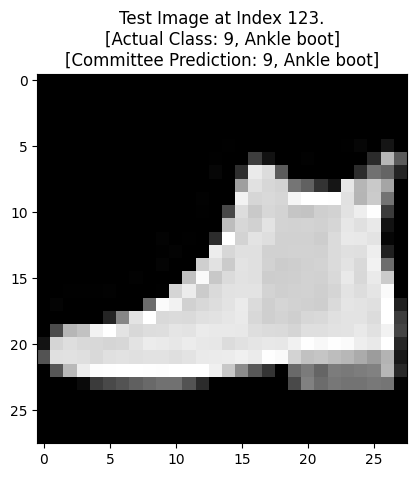

In [26]:
import matplotlib.pyplot as plt

classes={'0':'T-shirt/top',
'1':'Trouser',
'2':'Pullover',
'3':'Dress',
'4':'Coat',
'5':'Sandal',
'6':'Shirt',
'7':'Sneaker',
'8':'Bag',
'9':'Ankle boot'}

def predict_test_image(index, models, test_images_sets, test_labels):
    # Ensure index is within the range
    if index < 0 or index >= len(test_labels):
        print("Index out of range.")
        return

    # Models predictions
    individual_predictions = [model.predict(test_images_sets[i][index:index+1]) for i, model in enumerate(models)]
    individual_classes = [np.argmax(pred) for pred in individual_predictions]

    # Committee prediction
    avg_prediction = np.mean(individual_predictions, axis=0)
    committee_class = np.argmax(avg_prediction)

    # Actual class
    actual_class = test_labels[index]

    # Display results
    print(f"Predictions: CNN: {individual_classes[0]}- {classes[str(individual_classes[0])]}, MLP: {individual_classes[1]}- {classes[str(individual_classes[1])]}, RNN: {individual_classes[2]} - {classes[str(individual_classes[2])]}")
    print(f"Committee Prediction: {committee_class}, {classes[str(committee_class)]}")
    print(f"Actual Class: {actual_class}, {classes[str(actual_class)]}")

    # Display the image
    plt.imshow(test_images_sets[0][index].reshape(28, 28), cmap='gray')
    plt.title(f"Test Image at Index {index}.\n[Actual Class: {actual_class}, {classes[str(actual_class)]}]\n[Committee Prediction: {committee_class}, {classes[str(committee_class)]}]")
    plt.show()

 
# Example usage
predict_test_image(index=123, models=[cnn_model, mlp_model, lstm_model], test_images_sets=[test_images_cnn, test_images_mlp, test_images_lstm], test_labels=test_labels)


#### predict the image in the index 1322

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Predictions: CNN: 2- Pullover, MLP: 2- Pullover, RNN: 2 - Pullover
Committee Prediction: 2, Pullover
Actual Class: 2, Pullover


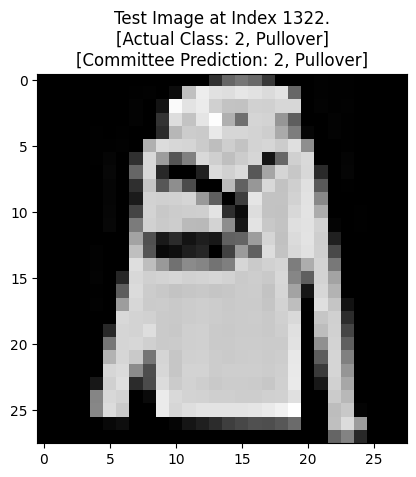

In [27]:
predict_test_image(index=1322, models=[cnn_model, mlp_model, lstm_model], test_images_sets=[test_images_cnn, test_images_mlp, test_images_lstm], test_labels=test_labels)

#### predict the image in the index 902

1/1 [==============================] - 0s 15ms/step
Predictions: CNN: 5- Sandal, MLP: 7- Sneaker, RNN: 9 - Ankle boot
Committee Prediction: 9, Ankle boot
Actual Class: 5, Sandal


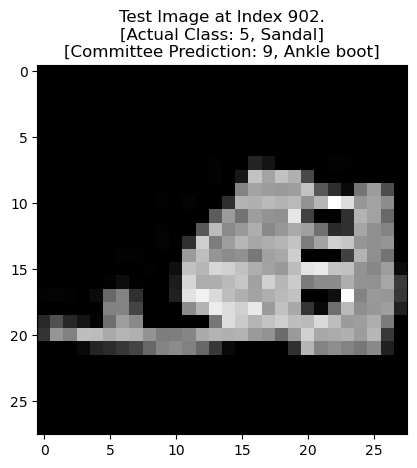

In [23]:
predict_test_image(index=902, models=[cnn_model, mlp_model, lstm_model], test_images_sets=[test_images_cnn, test_images_mlp, test_images_lstm], test_labels=test_labels)